# Recordings, signals and streaming

`medusa.core.data` is the runtime data model of the MEDUSA ecosystem: a
BIDS-aligned set of containers for the data captured in one **recording**
(one run). This tutorial walks through the key pieces.

In this notebook you will learn how to:

- build a `Recording` from scratch — typed channels, signals, events and
  metadata;
- save and load it across formats (HDF5, BSON, JSON, MAT) with one API;
- acquire data in real time with a `Recorder` (an in-RAM ring buffer plus
  optional continuous HDF5 persistence).

The synthetic signals come from `medusa.signal.generators`, so the
notebook runs anywhere with no dataset download.

## Imports

<div class="alert alert-block alert-danger">
Important: execute the following cell <b>only</b> if you're using Google Colab!
</div>

In [1]:
!pip install medusa-kernel

Import the modules we will use:

In [2]:
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from medusa.core.data import (BidsInfo, Recording, Recorder, Signal, Events,
                              Channel, ChannelSet)
from medusa.signal.generators import EEGSignalGenerator

warnings.simplefilter("ignore")          # keep the tutorial output tidy
rng = np.random.default_rng(0)           # deterministic
RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)   # saved files land here

## Channels and a Signal

A `ChannelSet` describes the columns of a recording, mirroring the BIDS
split between **channels** (data columns, each with a `ch_type` such as
`EEG`/`EMG`) and **sensors** (the physical transducers and their
positions). A `Signal` is one acquisition stream: one device, one sampling
rate `fs`, and one `[n_samples x n_channels]` matrix whose columns are
typed by the channel set.

We synthesise the EEG with `EEGSignalGenerator` (a `1/f` background plus an
alpha rhythm, in microvolts).

In [3]:
fs = 256.0
eeg_cs = ChannelSet().add_unipolar_eeg_channels(["Fz", "Cz", "Pz", "Oz"])

eeg_data = EEGSignalGenerator(fs=fs, seed=0).get_chunk(4.0, eeg_cs.n_channels)
eeg = Signal(eeg_data, fs=fs, channel_set=eeg_cs)
print(eeg)
print("channels:", eeg.channel_set.uids)
print("types:   ", sorted(set(eeg.channel_set.types)))

Signal(n_samples=1024, n_channels=4, fs=256.0, types=['EEG'])
channels: ['Fz', 'Cz', 'Pz', 'Oz']
types:    ['EEG']


## A Recording: streams, events and metadata

A `Recording` groups everything captured in one run around a shared time
origin: its BIDS identity (`BidsInfo`), one or more `Signal` streams in
`data` (multiple devices are first-class — each is its own stream), a
per-stream metadata sidecar, a BIDS `events` timeline, and a free-form
`experiment` slot for paradigm/setup information that BIDS does not
model.

In [4]:
rec = Recording(BidsInfo(subject="01", task="gonogo", run=1,
                         participant={"age": 27, "sex": "F"}))
rec.add_signal("eeg", eeg)

# a second device: 2-channel EMG at a different sampling rate
emg_cs = ChannelSet().add_channels([Channel("EMG_left", "EMG", "uV"),
                                    Channel("EMG_right", "EMG", "uV")])
rec.add_signal("emg", Signal(50.0 * rng.standard_normal((int(4 * 2000), 2)),
                             fs=2000.0, channel_set=emg_cs))

# events timeline + free-form experiment metadata
events = Events(optional_columns={"trial_type": str, "value": int})
events.append([{"onset": 0.5, "duration": 0.2, "trial_type": "go", "value": 1},
               {"onset": 1.5, "duration": 0.2, "trial_type": "nogo", "value": 2}])
rec.set_events(events)
rec.set_experiment({"paradigm": "go/no-go", "monitor_refresh_hz": 60})

# per-stream sidecar: derivable fields are auto-filled; device fields set by hand
rec.set_sidecar("eeg", Manufacturer="Brain Products")

print(rec)
print("streams:", list(rec.data))
print("eeg sidecar:", {k: rec.sidecars["eeg"][k] for k in
                       ("SamplingFrequency", "EEGChannelCount", "Manufacturer")})

Recording(sub-01_task-gonogo_run-1, data=['eeg', 'emg'], events=True, experiment=True)
streams: ['eeg', 'emg']
eeg sidecar: {'SamplingFrequency': 256.0, 'EEGChannelCount': 4, 'Manufacturer': 'Brain Products'}


## Save and load — one API, many formats

`recording.save(path)` and `Recording.load(path)` pick the format from the
file extension. `bson`/`json`/`mat` back the multiplatform interchange;
`hdf5` adds a binary, growable format. All round-trip the same object
losslessly. Here we write into the `results/` folder.

In [5]:
for fmt in ("h5", "bson", "json", "mat"):
    path = RESULTS / f"sub-01_task-gonogo_run-1.{fmt}"
    rec.save(str(path))
    back = Recording.load(str(path))
    lossless = np.allclose(back.signals["eeg"].signal, rec.signals["eeg"].signal)
    print(f".{fmt:4s}  {path.stat().st_size // 1024:5d} KB   lossless={lossless}")

.h5      196 KB   lossless=True
.bson    435 KB   lossless=True
.json   1548 KB   lossless=True
.mat     242 KB   lossless=True


## Real-time acquisition with a Recorder

During acquisition you usually do not have the full signal yet — chunks
arrive over time. A `Recorder` handles that: each `append_data` grows the
recording's own `Signal` **in place**, trimmed to the last `buffer` seconds,
so `recording.signals[key]` is a live, bounded window you can process
directly. Passing a `file` also persists the *full* stream to one HDF5 file
(crash-safe).

Declare the empty streams up front with `Signal.empty`, then stream chunks
from an `EEGSignalGenerator` into the `Recorder`.

In [6]:
live = Recording(BidsInfo(subject="01", task="gonogo", run=2))
live.add_signal("eeg", Signal.empty(fs=256.0, channel_set=eeg_cs))

stream_gen = EEGSignalGenerator(fs=256.0, seed=1)
h5_path = RESULTS / "sub-01_task-gonogo_run-2.h5"
with Recorder(live, file=str(h5_path), buffer=1.0) as recorder:  # last 1 s in RAM + file
    for _ in range(8):                                           # eight 0.25 s chunks
        recorder.append_data("eeg", stream_gen.get_chunk(0.25, eeg_cs.n_channels))

# the in-RAM buffer holds the last second; the full stream is on disk
print("live buffer:", live.signals["eeg"].n_samples, "samples (= last 1 s)")
full = Recording.load(str(h5_path))
print("on disk:    ", full.signals["eeg"].n_samples, "samples (full stream)")

live buffer: 256 samples (= last 1 s)
on disk:     512 samples (full stream)


The live buffer is a normal `Signal`, so it pipes straight into the
processing layer (e.g. `pick_types`) or a plot:

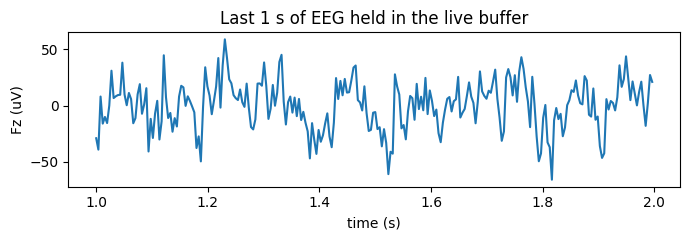

In [7]:
window = live.signals["eeg"]
plt.figure(figsize=(7, 2.5))
plt.plot(window.times, window.signal[:, 0])
plt.xlabel("time (s)")
plt.ylabel("Fz (uV)")
plt.title("Last 1 s of EEG held in the live buffer")
plt.tight_layout()
plt.show()

## Conclusion

You have seen the core of `medusa.core.data`:

- `ChannelSet` + `Signal` model a typed acquisition stream;
- `Recording` groups streams, events, sidecars and free-form `experiment`
  metadata under one BIDS identity;
- `save`/`load` round-trip it across HDF5, BSON, JSON and MAT;
- `Recorder` streams data live — an in-RAM bounded buffer for real-time
  processing plus optional continuous HDF5 persistence.

See you in the next MEDUSA tutorial!